In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from tabm import TabM
from pytabkit import RealMLP_TD_Classifier
from rtdl_num_embeddings import LinearReLUEmbeddings
from autogluon.tabular import TabularPredictor
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score
import itertools
import sys
# Get the current working directory of the notebook
current_dir = os.getcwd()
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from imputation import * 
from internal_test import *
from summary_table import *
from feature_importance import *
# Show all rows
pd.set_option('display.max_rows', None)
# Show all columns
pd.set_option('display.max_columns', None)
# Do not truncate column values
pd.set_option('display.max_colwidth', None)

/Users/jiaxinying/Desktop/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
year = '2000-2006'

In [3]:
# Define input columns and target
X_columns = [
    #'hhidpn', 'NIWWAVE','demcls',
     'child', 'lbrf', 'shlt', 'ageym', 'height', 'weight', 'smokev', 'proxy', 'effort', 'hibpe', 'diabe', 'vgactx', 'slfmem', 'livpar', 'momage', 'dadage', 'livsib', 'hlthlm', 'hosp', 'nrshom', 'nrstim', 'nrsnit', 'doctim', 'depres', 'sleepr', 'whappy', 'flone', 'fsad', 'going', 'enlife', 'drink', 'smoken', 'cancre', 'lunge', 'hearte', 'stroke', 'arthre', 'toilta', 'adl5a', 'mapa', 'walksa', 'walk1a', 'sita', 'chaira', 'climsa', 'clim1a', 'stoopa', 'lifta', 'dimea', 'armsa', 'pusha', 'mobila', 'lgmusa', 'grossa', 'finea', 'gender', 'edstg2 8to11', 'edstg3 12', 'edstg4 13above', 'cendiv2 mid atlantic', 'cendiv3 en central', 'cendiv4 wn central', 'cendiv5 s atlantic', 'cendiv6 es central', 'cendiv7 ws central', 'cendiv8 mountain', 'cendiv9 pacific', 'cendiv11 not us or inc us terr', 'mstat2 married spouse absent', 'mstat3 partnered', 'mstat4 separated', 'mstat5 divorced', 'mstat7 widowed', 'mstat8 never married', 'raceeth1 ', 'raceeth2 ', 'raceeth3 '
]

y_column = 'y'

# Directories and file paths
grid_search_dir = f'../data/{year}'

In [4]:
# Define grid search parameter grid
param_grid = {
    'batch_size': [128, 256],
    'n_epochs': [50, 100]
}

In [7]:
imputation_methods = ['none','mean','mice']  

In [8]:
final_rows, X_test, y_test, final_model = internal_test(year,RealMLP_TD_Classifier,param_grid,imputation_methods,grid_search_dir,X_columns, y_column)


Internal Test (2000-2006)
Model: <class 'pytabkit.models.sklearn.sklearn_interfaces.RealMLP_TD_Classifier'>
Protocol: 10-Fold Cross-Validation with 8:1:1 Train : Validation : Test splits
Metrics are reported as percentages with two decimal places.


Processing imputation method: none


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True

For imputation method 'none', best candidate: (128, 100) with average validation AUPR = 17.64%


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: T

Final test metrics for imputation method 'none': AUC = 79.95%, ACC = 96.50%, AUPR = 17.42%
Standard deviations across folds (for error bars): AUC_std = 4.88%, ACC_std = 0.29%, AUPR_std = 5.48%

Processing imputation method: mean


...

Final test metrics for imputation method 'mean': AUC = 82.67%, ACC = 96.50%, AUPR = 20.71%
Standard deviations across folds (for error bars): AUC_std = 3.11%, ACC_std = 0.31%, AUPR_std = 4.63%

Processing imputation method: mice


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True

For imputation method 'mice', best candidate: (256, 50) with average validation AUPR = 22.98%


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (m

Final test metrics for imputation method 'mice': AUC = 80.87%, ACC = 96.51%, AUPR = 20.03%
Standard deviations across folds (for error bars): AUC_std = 3.51%, ACC_std = 0.32%, AUPR_std = 5.99%


#### Internal Test with stratified data splitting via miceforest imputation
##### Train:Val:Test = 6:2:2

In [9]:
df_full = pd.read_csv('../data/preprocessed data/2000(00-06y)encode.csv')
X_full, y_full = impute_data_and_y(df_full, 'mice', X_columns, y_column)

In [10]:
train_sets = []
train_val_sets = []
val_sets = []
test_sets = []
for i in range(10):
    # make train+val and test data split 8:2
    X_train_val, X_test, y_train_val, y_test = train_test_split(X_full, y_full, test_size=0.2, stratify=y_full, random_state=i)
    train_val_sets.append((X_train_val, y_train_val))
    test_sets.append((X_test, y_test))
    # make train and val data split 6:2. finally train:val:test = 6:2:2
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=i)
    train_sets.append((X_train, y_train))
    val_sets.append((X_val, y_val))

In [11]:
#grid search
candidate_results = {}
for train, val in zip(train_sets,val_sets ):
    X_train, y_train = train
    X_val, y_val = val
    combinations = itertools.product(*param_grid.values())
    for parameter in combinations:
        candidate = list(param_grid.keys())
        try:
            m = RealMLP_TD_Classifier(**dict(zip(candidate, parameter)))
            m.fit(X_train, y_train)
            y_val_prob = m.predict_proba(X_val)[:, 1]
            aupr = average_precision_score(y_val, y_val_prob)
            candidate_results.setdefault(parameter, []).append(aupr)
        except Exception:
            continue
avg_val_aupr = {cand: np.mean(scores) for cand, scores in candidate_results.items()}
best_candidate = max(avg_val_aupr, key=avg_val_aupr.get)
best_val_aupr = avg_val_aupr[best_candidate]
print(
    f"For imputation method 'mice', best candidate: {best_candidate} "
    f"with average validation AUPR = {pct(best_val_aupr)}"
        )

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=50` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True

For imputation method 'mice', best candidate: (128, 100) with average validation AUPR = 30.11%


In [12]:
per_fold = []
optimal_thresholds_list = []

# Step 1: Find optimal threshold for each fold
for train_val, test in zip(train_val_sets, test_sets):
    X_train_val, y_train_val = train_val
    X_test, y_test = test
    final_model = RealMLP_TD_Classifier(**dict(zip(candidate, best_candidate)))
    final_model.fit(X_train_val, y_train_val)
    y_prob = final_model.predict_proba(X_test)[:, 1]
    
    # Find optimal threshold based on F1 score
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
    
    optimal_thresholds_list.append(optimal_threshold)

# Step 2: Use mean optimal threshold for all folds
mean_optimal_threshold = np.mean(optimal_thresholds_list)
print(f"Mean Optimal Threshold: {mean_optimal_threshold:.4f}")
print(f"Optimal thresholds per fold: {[f'{t:.4f}' for t in optimal_thresholds_list]}")

# Step 3: Calculate metrics using optimal threshold
per_fold = []
for train_val, test in zip(train_val_sets, test_sets):
    X_train_val, y_train_val = train_val
    X_test, y_test = test
    final_model = RealMLP_TD_Classifier(**dict(zip(candidate, best_candidate)))
    final_model.fit(X_train_val, y_train_val)
    y_prob = final_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= mean_optimal_threshold).astype(int)
    
    per_fold.append({
        "AUC": roc_auc_score(y_test, y_prob),
        "ACC": accuracy_score(y_test, y_pred),
        "AUPR": average_precision_score(y_test, y_prob),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    })

# Step 4: Calculate means and stds across folds
aucs      = np.array([m["AUC"]       for m in per_fold])
accs      = np.array([m["ACC"]       for m in per_fold])
auprs     = np.array([m["AUPR"]      for m in per_fold])
precisions = np.array([m["Precision"] for m in per_fold])
recalls   = np.array([m["Recall"]    for m in per_fold])
f1s       = np.array([m["F1"]        for m in per_fold])

mean_auc,  std_auc  = aucs.mean(),  aucs.std()
mean_acc,  std_acc  = accs.mean(),  accs.std()
mean_aupr, std_aupr = auprs.mean(), auprs.std()
mean_precision, std_precision = precisions.mean(), precisions.std()
mean_recall,    std_recall    = recalls.mean(),    recalls.std()
mean_f1,        std_f1        = f1s.mean(),        f1s.std()

print("\nRealMLP_TD_Classifier with MICE Imputation — Internal Test")
print(f"Optimal Threshold Used: {mean_optimal_threshold:.4f}")
print(
    f"Final test metrics: "
    f"AUC = {pct(mean_auc)}, ACC = {pct(mean_acc)}, AUPR = {pct(mean_aupr)}, "
    f"Precision = {pct(mean_precision)}, Recall = {pct(mean_recall)}, F1 = {pct(mean_f1)}"
)
print(
    f"Standard deviations across folds: "
    f"AUC_std = {pct(std_auc)}, ACC_std = {pct(std_acc)}, AUPR_std = {pct(std_aupr)}, "
    f"Precision_std = {pct(std_precision)}, Recall_std = {pct(std_recall)}, F1_std = {pct(std_f1)}"
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: T

Mean Optimal Threshold: 0.1836
Optimal thresholds per fold: ['0.2100', '0.1969', '0.1562', '0.1847', '0.1748', '0.2335', '0.1460', '0.1701', '0.1663', '0.1974']


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: T


RealMLP_TD_Classifier with MICE Imputation — Internal Test
Optimal Threshold Used: 0.1836
Final test metrics: AUC = 80.45%, ACC = 81.78%, AUPR = 28.50%, Precision = 26.86%, Recall = 55.33%, F1 = 35.83%
Standard deviations across folds: AUC_std = 1.16%, ACC_std = 2.12%, AUPR_std = 1.93%, Precision_std = 1.39%, Recall_std = 9.18%, F1_std = 1.42%


In [13]:
result = permutation_importance(
    final_model, X_test, y_test, scoring="average_precision",n_repeats=10, random_state=42, n_jobs=2
)

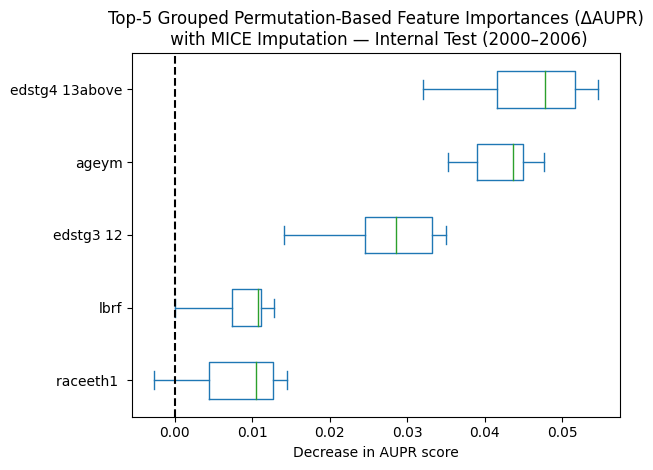

In [14]:
sorted_importances_idx = result.importances_mean.argsort()[-5:]
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Top-5 Grouped Permutation-Based Feature Importances (ΔAUPR)\n with MICE Imputation — Internal Test (2000–2006)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in AUPR score")
ax.figure.tight_layout()

In [15]:
print("Top-5 Grouped Permutation-Based Feature Importances (ΔAUPR)\nRealMLP with MICE Imputation — Internal Test (2000–2006)")

pd.DataFrame(
    result.importances[result.importances_mean.argsort()][::-1].T,
    columns=X_test.columns[result.importances_mean.argsort()[::-1]],
).mean()[:5].round(3)

Top-5 Grouped Permutation-Based Feature Importances (ΔAUPR)
RealMLP with MICE Imputation — Internal Test (2000–2006)


edstg4 13above    0.046
ageym             0.042
edstg3 12         0.028
lbrf              0.009
raceeth1          0.008
dtype: float64